In [1]:
import pandas as pd

df = pd.read_csv("superstore_sales_cleaned.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
X = df[['Shipping Days']]
y = df['Sales']

print("Input (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

KeyError: "None of [Index(['Shipping Days'], dtype='object')] are in the [columns]"

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

df[['Order Date', 'Ship Date', 'Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [4]:
X = df[['Shipping Days']]
y = df['Sales']

print("Input (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Input (X):
   Shipping Days
0              3
1              3
2              4
3              7
4              7

Target (y):
0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: Sales, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7840, 1)
Testing data: (1960, 1)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

print("Linear Regression model created!")

Linear Regression model created!


In [7]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[221.032596   219.19743212 228.37325149 221.032596   221.032596
 226.53808762 221.032596   224.70292374 217.36226825 219.19743212]


In [9]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values[:10],
    'Predicted Sales': y_pred[:10]
})

comparison

,Actual Sales,Predicted Sales
0,47.940,221.032596
1,11.360,219.197432
2,10.950,228.373251
3,17.480,221.032596
4,21.120,221.032596
5,88.832,226.538088
6,6.672,221.032596
7,22.480,224.702924
8,251.580,217.362268
9,38.256,219.197432


In [10]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 303.06475519498144


In [11]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: -1.8351638735576745
Intercept: 228.37325149109347


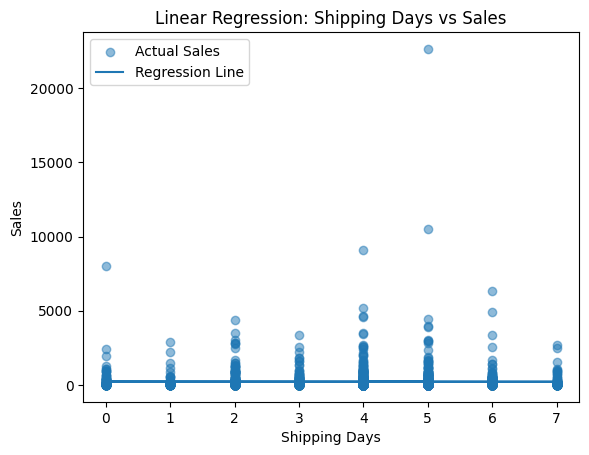

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, alpha=0.5, label='Actual Sales')
plt.plot(X_test, y_pred, label='Regression Line')

plt.xlabel('Shipping Days')
plt.ylabel('Sales')
plt.title('Linear Regression: Shipping Days vs Sales')
plt.legend()
plt.show()

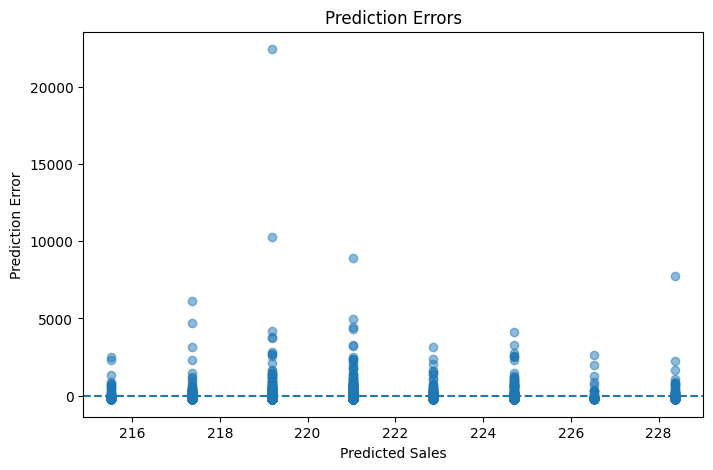

In [13]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, errors, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Sales')
plt.ylabel('Prediction Error')
plt.title('Prediction Errors')
plt.show()

In [14]:
reg_df = df.copy()

reg_df['Order Year'] = reg_df['Order Date'].dt.year

features = [
    'Shipping Days',
    'Order Year',
    'Category',
    'Sub-Category',
    'Region',
    'Ship Mode',
    'Segment'
]

X = reg_df[features]
y = reg_df['Sales']

print("Features selected:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features selected:
['Shipping Days', 'Order Year', 'Category', 'Sub-Category', 'Region', 'Ship Mode', 'Segment']

Target:
Sales


In [15]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        'Category',
        'Sub-Category',
        'Region',
        'Ship Mode',
        'Segment'
    ],
    dtype=int
)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)

Before encoding: (9800, 7)
After encoding: (9800, 33)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7840, 33)
Testing data: (1960, 33)


In [17]:
improved_model = LinearRegression()

print("Improved Linear Regression model created!")

Improved Linear Regression model created!


In [18]:
improved_model.fit(X_train, y_train)

print("Improved model trained successfully!")

Improved model trained successfully!


In [19]:
y_pred_improved = improved_model.predict(X_test)

print("First 10 improved predictions:")
print(y_pred_improved[:10])

First 10 improved predictions:
[ 93.76780107  65.5986444  333.37260031 221.81294723  54.91448334
 210.74818903 143.47692784  36.26334197  72.44984099  33.11634396]


In [20]:
mae_improved = mean_absolute_error(y_test, y_pred_improved)

print("Improved Model MAE:", mae_improved)

Improved Model MAE: 238.76911115425153


In [21]:
print("Regression Model Comparison")
print("---------------------------")
print("Baseline Model MAE :", round(mae, 2))
print("Improved Model MAE :", round(mae_improved, 2))

improvement = ((mae - mae_improved) / mae) * 100

print("Improvement        :", round(improvement, 2), "%")

Regression Model Comparison
---------------------------
Baseline Model MAE : 303.06
Improved Model MAE : 238.77
Improvement        : 21.22 %


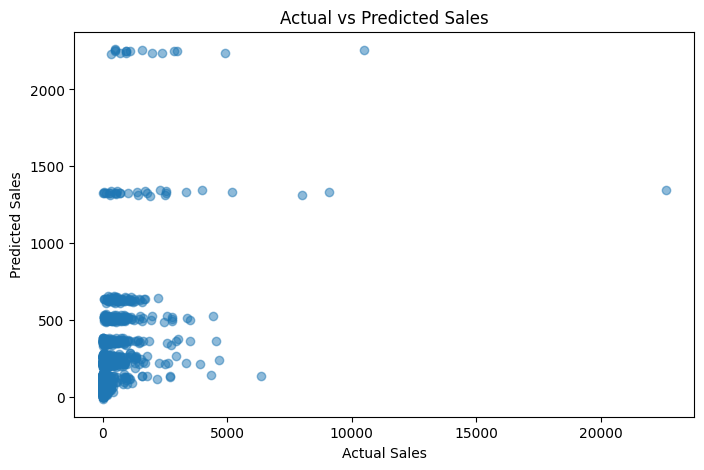

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_improved, alpha=0.5)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

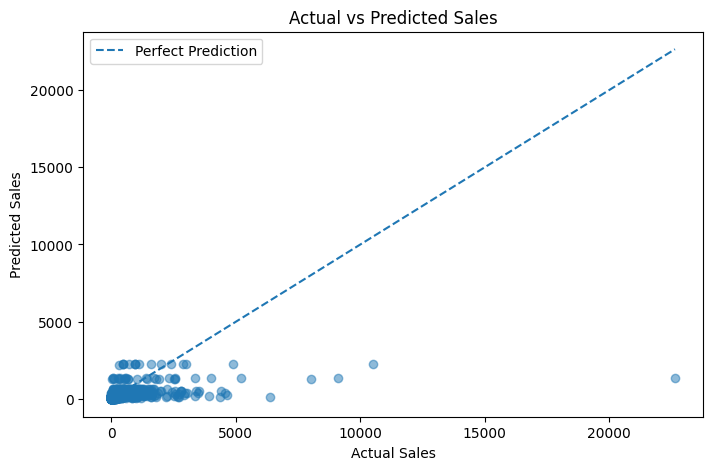

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_improved, alpha=0.5)

max_value = max(y_test.max(), y_pred_improved.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()

In [24]:
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': improved_model.coef_
})

coefficients['Absolute Coefficient'] = coefficients['Coefficient'].abs()

coefficients.sort_values(
    'Absolute Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient,Absolute Coefficient
11,Sub-Category_Copiers,1315.333009,1315.333009
5,Sub-Category_Accessories,-715.773231,715.773231
18,Sub-Category_Phones,-572.310075,572.310075
4,Category_Technology,419.526548,419.526548
16,Sub-Category_Machines,392.276845,392.276845
14,Sub-Category_Furnishings,-359.305360,359.305360
3,Category_Office Supplies,-358.924897,358.924897
21,Sub-Category_Tables,180.738539,180.738539
13,Sub-Category_Fasteners,-141.285710,141.285710
7,Sub-Category_Art,-122.513482,122.513482


In [25]:
regression_results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred_improved,
    'Prediction Error': y_test.values - y_pred_improved
})

regression_results.to_csv(
    'day12_regression_predictions.csv',
    index=False
)

print("Regression predictions saved successfully!")

Regression predictions saved successfully!


# Day 12 – Regression Modeling

## Objective
Built and evaluated Linear Regression models to predict continuous Sales values.

## What I Did
- Selected input features and Sales as the target
- Built a baseline Linear Regression model using Shipping Days
- Generated predictions and evaluated prediction errors
- Interpreted regression coefficients
- Created prediction and error visualizations
- Built an improved model using multiple features
- Compared baseline and improved model performance

## Baseline Model
Feature used:
- Shipping Days

Mean Absolute Error:
- 303.06

## Improved Model
Features used:
- Shipping Days
- Order Year
- Category
- Sub-Category
- Region
- Ship Mode
- Segment

After One-Hot Encoding:
- 33 numerical features

Mean Absolute Error:
- 238.77

## Model Improvement
The improved model reduced MAE from 303.06 to 238.77.

Improvement:
- 21.21%

## Visualizations
- Linear Regression line
- Prediction errors
- Actual vs Predicted Sales
- Perfect prediction reference line

## Key Learning
Regression models learn relationships between input features and a continuous numerical target.

Using more meaningful features improved the model's prediction performance compared with using Shipping Days alone.

## Output
Prediction results were saved as:

`day12_regression_predictions.csv`